In [14]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import squidpy as sq


In [2]:
adata = sc.read_h5ad("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/2026-03-27_analysis_run/subset_adata/TOY.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 174181 × 5099
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'ROI', 'batch', 'condition', 'sample_ID', 'timepoint', 'timepoint_label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_res_0.1', 'leiden_res_0.3', 'leiden_res_0.5', 'leiden_res_0.8', 'leiden_res_1.0', 'leiden_best', 'level_0_annotation', 'level_1', 'level_2', 'level_3', 'Condition_meta', 'Sample_ID', 'Timepoint', 'Lung_location', 'Biopsy_type', 'Treatment_arm', 'Age', 'Gender'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts',

In [21]:
gene = "MUC5AC"
expr_df = adata.obs[["timepoint", "Treatment_arm"]].copy()

expr_values = adata[:, gene].layers["counts"]
if hasattr(expr_values, "toarray"):
    expr_values = expr_values.toarray().ravel()
else:
    expr_values = np.asarray(expr_values).ravel()

expr_df[gene] = expr_values
expr_df

,timepoint,Treatment_arm,MUC5AC
COPD_R009_V1_0,V1,Sham,0.0
COPD_R009_V1_1,V1,Sham,0.0
COPD_R009_V1_2,V1,Sham,0.0
COPD_R009_V1_4,V1,Sham,0.0
COPD_R009_V1_5,V1,Sham,0.0
...,...,...,...
COPD_R011_V3_15454,V3,Treatment,0.0
COPD_R011_V3_15455,V3,Treatment,0.0
COPD_R011_V3_15456,V3,Treatment,0.0
COPD_R011_V3_15457,V3,Treatment,0.0


In [ ]:
import pandas as pd
import numpy as np

def mean_expression_per_roi_celltype(
    adata,
    gene,
    roi_col="ROI",
    celltype_col="level_1",
    celltype=None,
    layer="lognorm",
    include_zeros=True,
):
    """Calculate mean gene expression per ROI for a chosen cell type.

    Args:
    adata : AnnData
    gene : str
        Gene to compute mean expression for.
    roi_col : str
        Column in adata.obs with ROI labels. Default: "ROI".
    celltype_col : str
        Column in adata.obs with cell type annotations. Default: "level_1".
    celltype : str or list of str, optional
        Cell type(s) to subset to. If None, uses all spots.
    layer : str
        Layer to pull expression from. Default: "lognorm".
        Set to None to use adata.X.
    include_zeros : bool
        If True (default), mean includes zero-expressing spots.
        If False, mean is computed only over spots with expression > 0,
        and 'pct_expressing' column is also returned.

    Returns:
    pd.DataFrame with columns:
        - roi_col         : ROI label
        - 'mean_expr'     : mean expression across spots
        - 'n_spots'       : total spots in that ROI (after cell type filter)
        - 'pct_expressing': % spots with expression > 0 (always included)
    """
    # Validate inputs
    if gene not in adata.var_names:
        raise ValueError(f"Gene '{gene}' not found in adata.var_names.")
    if roi_col not in adata.obs.columns:
        raise ValueError(f"'{roi_col}' not found in adata.obs.")
    if celltype_col not in adata.obs.columns:
        raise ValueError(f"'{celltype_col}' not found in adata.obs.")

    #  Subset to chosen cell type(s)
    if celltype is not None:
        if isinstance(celltype, str):
            celltype = [celltype]
        mask = adata.obs[celltype_col].isin(celltype)
        sub = adata[mask].copy()
        if sub.n_obs == 0:
            raise ValueError(
                f"No spots found for cell type(s) {celltype} in '{celltype_col}'."
            )
    else:
        sub = adata

    #  Extract expression
    if layer is not None:
        expr = sub[:, gene].layers[layer]
    else:
        expr = sub[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    else:
        expr = np.asarray(expr).flatten()

    df = sub.obs[[roi_col]].copy()
    df["expression"] = expr

    #  Aggregate per ROI
    def agg(grp):
        n_total = len(grp)
        n_expr  = (grp["expression"] > 0).sum()
        pct     = 100 * n_expr / n_total if n_total > 0 else np.nan
        if include_zeros:
            mean = grp["expression"].mean()
        else:
            nonzero = grp["expression"][grp["expression"] > 0]
            mean = nonzero.mean() if len(nonzero) > 0 else np.nan
        return pd.Series({
            "mean_expr":      mean,
            "n_spots":        n_total,
            "n_expressing":   n_expr,
            "pct_expressing": pct,
        })

    result = df.groupby(roi_col).apply(agg).reset_index()
    result.attrs["gene"]      = gene
    result.attrs["celltype"]  = celltype
    result.attrs["layer"]     = layer

    return result

In [29]:
adata.obs["level_2"].value_counts()

level_2
Goblet cells                              27697
Basal cells                               23453
Unknown                                   21793
Ciliated cells                            20389
Adventitial fibroblasts                   17789
SMC                                       12210
Secretory epithelial cells                11992
Pulmonary vein endothelial cell            8353
Blood endothelial cells - unclassified     3892
Plasma cells                               3165
Macrophages                                3133
Interstitial Macrophages                   2522
CD8+ T cells                               2453
T cells                                    2144
Pericytes                                  1916
Lymphatic endothelial cells                1774
Mast cells                                 1674
Dendritic cells                            1520
NK cells                                   1318
CD4+ T cells                               1023
Alveolar fibroblasts            

In [33]:
def map_metadata_to_roi_df(
    roi_df,
    adata,
    roi_col="ROI",
    metadata_cols=None,
):
    """Map metadata from adata.obs to a per-ROI summary DataFrame.

    Since each ROI may contain many spots, metadata is extracted by taking
    the unique value per ROI (for constant fields like timepoint/condition)
    or raising a warning if a column is not constant within an ROI.

    Args:
    roi_df : pd.DataFrame
        Output of mean_expression_per_roi_celltype(), must contain roi_col.
    adata : AnnData
        Source AnnData object.
    roi_col : str
        Column name used to match ROIs between roi_df and adata.obs.
        Default: "ROI".
    metadata_cols : list of str, optional
        Columns from adata.obs to map onto roi_df.
        If None, maps ALL columns except roi_col.

    Returns:
    pd.DataFrame
        roi_df with metadata columns appended.
    """
    # ── Validate ───────────────────────────────────────────────────────────────
    if roi_col not in adata.obs.columns:
        raise ValueError(f"'{roi_col}' not found in adata.obs.")
    if roi_col not in roi_df.columns:
        raise ValueError(f"'{roi_col}' not found in roi_df.")

    # ── Resolve which columns to map ───────────────────────────────────────────
    if metadata_cols is None:
        metadata_cols = [c for c in adata.obs.columns if c != roi_col]
    else:
        missing = [c for c in metadata_cols if c not in adata.obs.columns]
        if missing:
            raise ValueError(f"Columns not found in adata.obs: {missing}")

    # ── Build ROI-level metadata from adata.obs ────────────────────────────────
    obs = adata.obs[[roi_col] + metadata_cols].copy()

    roi_meta = {}
    for col in metadata_cols:
        def agg_col(grp, col=col):
            unique_vals = grp[col].dropna().unique()
            if len(unique_vals) == 1:
                # Constant within ROI — safe to map directly
                return unique_vals[0]
            elif len(unique_vals) == 0:
                return np.nan
            else:
                # Not constant — warn and take the most frequent value
                most_frequent = grp[col].value_counts().idxmax()
                print(
                    f"  Warning: '{col}' has multiple values in ROI "
                    f"'{grp.name}': {unique_vals.tolist()}. "
                    f"Using most frequent: '{most_frequent}'."
                )
                return most_frequent

        roi_meta[col] = obs.groupby(roi_col).apply(agg_col)

    meta_df = pd.DataFrame(roi_meta).reset_index()  # roi_col + metadata cols

    # ── Merge onto roi_df ──────────────────────────────────────────────────────
    result = roi_df.merge(meta_df, on=roi_col, how="left")

    # ── Report any ROIs with no metadata match ─────────────────────────────────
    unmatched = result[result[metadata_cols[0]].isna()][roi_col].tolist()
    if unmatched:
        print(f"Warning: {len(unmatched)} ROI(s) in roi_df had no match in adata.obs: {unmatched}")

    return result

In [ ]:
# Single cell type
df = mean_expression_per_roi_celltype(
    adata,
    gene="MUC5AC",
    roi_col="ROI",
    celltype_col="level_2",
    celltype="Goblet cells",
    layer="counts",
)


df

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_60474/2989162836.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(roi_col).apply(agg).reset_index()
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_60474/2989162836.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby(roi_col).apply(agg).reset_index()


,ROI,mean_expr,n_spots,n_expressing,pct_expressing
0,COPD_R009_V1,0.501947,2568.0,452.0,17.601246
1,COPD_R009_V2,1.603270,3975.0,983.0,24.729560
2,COPD_R009_V3,4.485128,5850.0,3002.0,51.316239
3,COPD_R011_V1,1.757119,4776.0,1545.0,32.349246
4,COPD_R011_V2,1.556171,8305.0,2622.0,31.571343
5,COPD_R011_V3,4.739091,2223.0,1020.0,45.883941


In [34]:
roi_df = map_metadata_to_roi_df(
    df,
    adata,
    roi_col="ROI",
    metadata_cols=["timepoint", "Treatment_arm"],
)

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_60474/1582042375.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_meta[col] = obs.groupby(roi_col).apply(agg_col)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_60474/1582042375.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi_meta[col] = obs.groupby(roi_col).apply(agg_col)
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_60474/1582042375.py:65: FutureWarning: The default of observed=False is deprecated and will be ch

In [36]:
roi_df

,ROI,mean_expr,n_spots,n_expressing,pct_expressing,timepoint,Treatment_arm
0,COPD_R009_V1,0.501947,2568.0,452.0,17.601246,V1,Sham
1,COPD_R009_V2,1.603270,3975.0,983.0,24.729560,V2,Sham
2,COPD_R009_V3,4.485128,5850.0,3002.0,51.316239,V3,Sham
3,COPD_R011_V1,1.757119,4776.0,1545.0,32.349246,V1,Treatment
4,COPD_R011_V2,1.556171,8305.0,2622.0,31.571343,V2,Treatment
5,COPD_R011_V3,4.739091,2223.0,1020.0,45.883941,V3,Treatment


<Axes: xlabel='timepoint', ylabel='mean_expr'>

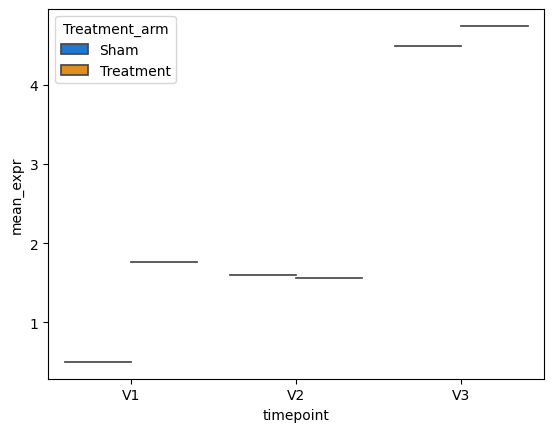

In [38]:
sns.violinplot(
    data=roi_df,
    x="timepoint",
    y="mean_expr",
    hue="Treatment_arm",
    hue_order=["Sham", "Treatment"],
    palette={"Sham": "#0279EE", "Treatment": "#FF9400"}
)

In [ ]:
sns.violinplot(
    data=expr_df,
    x="timepoint",
    y=gene,
    hue="Treatment_arm",
    #hue_order=["Sham", "Treatment"],
    split=True,   # mirrored violin for direct comparison
    inner="box",
    #palette={"Sham": "#0279EE", "Treatment": "#FF9400"}
)

In [ ]:
def plot_gene_spatial_timepoints(
    adata,
    gene,
    col_1="timepoint",
    col_2="Treatment_arm",
    layer="count",
    control_label=None,
    treatment_label=None,
    condition_order=None,
    cmap="viridis",
    figsize_per_panel=(5, 4),
    spot_size=None,
    save_path=None,
    dpi=150,
):
    """Plot spatial expression of a gene across multiple timepoints,
    with control and treatment side-by-side for direct comparison.

    Args:
    adata : AnnData
        Spatial AnnData object with spatial coordinates in obsm['spatial'].
    gene : str
        Gene name to plot (must be in adata.var_names).
    col_1 : str
        Column in adata.obs containing column information labels. Default: "timepoint".
    col_2 : str
        Column in adata.obs containing column information (e.g. Treatment_arm).
        Default: "Treatment_arm".
    layer : str
        Layer to use for expression values. Default: "count".
    control_label : str, optional
        Label for the control condition. If None, uses the first value
        (alphabetically) in condition_col.
    treatment_label : str, optional
        Label for the treatment condition. If None, uses the second value
        (alphabetically) in condition_col.
    condition_order : list of str, optional
        Explicit ordering of conditions (columns). Overrides control_label /
        treatment_label. E.g. ["Control", "DrugA", "DrugB"].
    cmap : str
        Matplotlib colormap for expression. Default: "viridis".
    figsize_per_panel : tuple
        (width, height) in inches for each individual spatial panel.
        Default: (5, 4).
    spot_size : float, optional
        Spot size passed to sq.pl.spatial_scatter. If None, squidpy default.
    save_path : str, optional
        File path to save the figure (e.g. "MUC5AC_spatial.png").
        If None, figure is not saved.
    dpi : int
        Resolution for saved figure. Default: 150.
    """  # noqa: D205
    # ── Validate gene ──────────────────────────────────────────────────────────
    if gene not in adata.var_names:
        raise ValueError(f"Gene '{gene}' not found in adata.var_names.")

    # ── Resolve condition order ────────────────────────────────────────────────
    if condition_order is not None:
        conditions = condition_order
    else:
        all_conditions = sorted(adata.obs[col_2].unique().tolist())
        if control_label is None:
            control_label = all_conditions[0]
        if treatment_label is None:
            treatment_label = [c for c in all_conditions if c != control_label][0]
        conditions = [control_label, treatment_label]

    # ── Resolve timepoint order ────────────────────────────────────────────────
    timepoints = sorted(adata.obs[col_1].unique().tolist())

    n_rows = len(timepoints)
    n_cols = len(conditions)

    # ── Shared colour scale (2nd–98th percentile, robust to outliers) ──────────
    gene_idx = list(adata.var_names).index(gene)
    expr_all = adata.layers[layer][:, gene_idx]
    if hasattr(expr_all, "toarray"):
        expr_all = expr_all.toarray().flatten()
    else:
        expr_all = np.asarray(expr_all).flatten()
    vmin = float(np.percentile(expr_all, 2))
    vmax = float(np.percentile(expr_all, 98))

    # ── Build figure ───────────────────────────────────────────────────────────
    w, h = figsize_per_panel
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(w * n_cols + 1, h * n_rows),  # +1 for colorbar space
        squeeze=False,
    )

    scatter_kwargs = dict(
        layer=layer,
        color=gene,
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
        show=False,
        cmap=cmap,
    )
    if spot_size is not None:
        scatter_kwargs["size"] = spot_size

    for row, tp in enumerate(timepoints):
        for col, cond in enumerate(conditions):
            ax = axes[row, col]

            mask = (
                (adata.obs[col_1] == tp) &
                (adata.obs[col_2] == cond)
            )
            sub = adata[mask].copy()

            if sub.n_obs == 0:
                ax.set_visible(False)
                continue

            sq.pl.spatial_scatter(sub, ax=ax, **scatter_kwargs)

            # Column headers (top row only)
            if row == 0:
                ax.set_title(cond, fontsize=13, fontweight="bold", pad=8)

            # Row labels (left column only)
            if col == 0:
                ax.set_ylabel(f"{col_1}: {tp}", fontsize=11, labelpad=6)
            else:
                ax.set_ylabel("")

            ax.set_xlabel("")

    # ── Shared colorbar ────────────────────────────────────────────────────────
    cbar_ax = fig.add_axes([1.002, 0.15, 0.018, 0.7])
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=f"{gene} ({layer})")

    fig.suptitle(gene, fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, axes